In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

In [84]:
minx, miny, maxx, maxy = -113, 44, -110, 46  # example bounds

df1 = pd.read_csv('/Users/chanagan/Downloads/CentennialMadisonGNSS/PayneGPS2012.csv',)
df2 = pd.read_csv('/Users/chanagan/Downloads/CentennialMadisonGNSS/Schmeelketal2017.csv',)
df = pd.concat([df1,df2])
def clean_numeric_array(arr):
    import numpy as np
    arr = np.asarray(arr, dtype=str)
    arr = np.char.replace(arr, '−', '-')  # Unicode minus → ASCII minus
    return arr.astype(float)
df['Longitude'] = np.asarray(clean_numeric_array(df.Longitude), dtype=float)
df['Latitude'] = np.asarray(clean_numeric_array(df.Latitude), dtype=float)
df['East Velocity (mm/yr)']  = np.asarray(clean_numeric_array(df['East Velocity (mm/yr)']), dtype=float)
df['North Velocity (mm/yr)'] = np.asarray(clean_numeric_array(df['North Velocity (mm/yr)']), dtype=float)
df['Longitude'] = df.Longitude[df.Longitude > 180] - 360
df = df[(df.Latitude < maxy)&(df.Latitude > miny)&(df.Longitude < maxx)&(df.Longitude > minx)]
df['ve'] = df['East Velocity (mm/yr)'].values - df[ df.Site == 'P707']['East Velocity (mm/yr)'].values[0]
df['vn'] = df['North Velocity (mm/yr)'].values - df[ df.Site == 'P707']['North Velocity (mm/yr)'].values[0]
faults = gpd.read_file("/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp")
faults = faults.cx[minx:maxx, miny:maxy]



In [85]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gps_velocities(
    lon,
    lat,
    ve,
    vn,
    crs='EPSG:4326',
    raster_path=None,
    faults=None,
    ax=None,
    scale=1,
    scale_vector=1,
    stride=1,
    cmap="gray",
    arrow_color="red",
    fault_color="black",
    fault_linewidth=1.0,
    figsize=(8, 8)
):
    """
    Plot GNSS velocity vectors with optional raster and fault overlays.

    Parameters
    ----------
    lon, lat : array-like
        Station coordinates (must match CRS of raster/faults if used).
    ve, vn : array-like
        East and north velocities.
    raster_path : str or None
        Path to raster (GeoTIFF).
    faults : GeoDataFrame or None
        Fault geometries (LineString/MultiLineString).
    ax : matplotlib axis (optional)
        Existing axis to plot on.
    """

    # --- Setup axis ---
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # --- Raster background (optional) ---
    if raster_path is not None:
        import rasterio
        from rasterio.plot import show

        with rasterio.open(raster_path) as src:
            show(src, ax=ax, cmap=cmap)


    # --- Subsample GNSS ---
    lon = np.asarray(lon)[::stride]
    lat = np.asarray(lat)[::stride]
    x, y, out_crs = project_points_if_needed(lon, lat, crs)
    ve = np.asarray(ve)[::stride]
    vn = np.asarray(vn)[::stride]

        # --- Faults (optional) ---
    if faults is not None:
        faults = project_gdf_if_needed(faults, out_crs)
        faults.plot(
            ax=ax,
            color=fault_color,
            linewidth=fault_linewidth,
            zorder=2
        )

    # --- Plot GNSS vectors ---
    q = ax.quiver(
        x, y,
        ve, vn,
        color=arrow_color,
        angles="xy",
        scale_units="xy",
        scale=scale,
        zorder=3,
        width=0.005,
    )

    # --- Reference vector ---
    ref = scale_vector
    ax.quiverkey(q, 0.1, 0.1, ref, f"{ref:.1f}", coordinates='axes')

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title("GNSS Velocity Field with Faults")

    return ax

<Axes: title={'center': 'GNSS Velocity Field with Faults'}, xlabel='Easting (m)', ylabel='Northing (m)'>

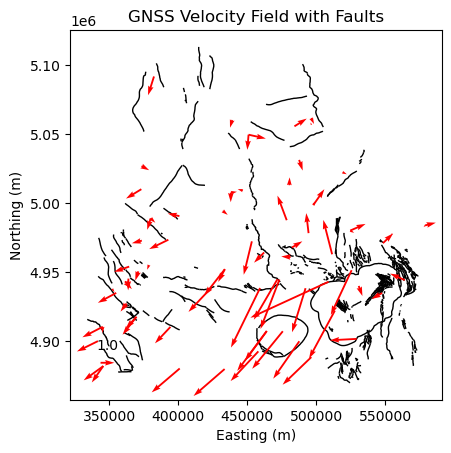

In [86]:
fig, ax = plt.subplots()
plot_gps_velocities(
    lon=df.Longitude,
    lat=df.Latitude,
    ve=df['East Velocity (mm/yr)'],
    vn=df['North Velocity (mm/yr)'],
    raster_path=None,
    faults=faults,
    scale=1e-4,
    ax = ax
)


# Plot strain and rake on fault

In [87]:
# id="proj_helpers"
from pyproj import CRS, Transformer
import numpy as np
import geopandas as gpd

def get_utm_crs(lon, lat):
    """Pick appropriate UTM CRS based on mean location."""
    lon0 = np.mean(lon)
    lat0 = np.mean(lat)

    zone = int((lon0 + 180) // 6) + 1
    epsg = 32600 + zone if lat0 >= 0 else 32700 + zone

    return CRS.from_epsg(epsg)

def project_points_if_needed(lon, lat, crs="EPSG:4326"):
    """
    Project lon/lat to UTM if input CRS is geographic.
    Returns x, y, and output CRS.
    """
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    if CRS.from_user_input(crs).is_geographic:
        utm_crs = get_utm_crs(lon, lat)
        transformer = Transformer.from_crs(crs, utm_crs, always_xy=True)
        x, y = transformer.transform(lon, lat)
        return x, y, utm_crs
    else:
        return lon, lat, CRS.from_user_input(crs)

def project_gdf_if_needed(gdf, target_crs):
    if gdf.crs != target_crs:
        return gdf.to_crs(target_crs)
    return gdf

# id="grid_projected"
from scipy.spatial import cKDTree

def grid_gps_velocity(lon, lat, ve, vn, spacing=2000, sigma=5000, crs="EPSG:4326"):
    """
    Grid GNSS velocities. spacing/sigma in meters if projected.
    """

    # --- project if needed ---
    x, y, out_crs = project_points_if_needed(lon, lat, crs)

    ve = np.asarray(ve, dtype=float)
    vn = np.asarray(vn, dtype=float)

    # --- grid in meters ---
    xi = np.arange(x.min(), x.max(), spacing)
    yi = np.arange(y.min(), y.max(), spacing)
    X, Y = np.meshgrid(xi, yi)

    tree = cKDTree(np.c_[x, y])

    Ve_grid = np.zeros_like(X)
    Vn_grid = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            dist, idx = tree.query([X[i, j], Y[i, j]], k=10)

            w = np.exp(-(dist**2) / (2 * sigma**2))
            if np.sum(w) == 0:
                Ve_grid[i, j] = np.nan
                Vn_grid[i, j] = np.nan
                continue

            w /= np.sum(w)

            Ve_grid[i, j] = np.sum(w * ve[idx])
            Vn_grid[i, j] = np.sum(w * vn[idx])

    return X, Y, Ve_grid, Vn_grid, out_crs

# id="strain_projected"
def compute_strain(X, Y, Ve, Vn):

    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]

    dVe_dy, dVe_dx = np.gradient(Ve, dy, dx)
    dVn_dy, dVn_dx = np.gradient(Vn, dy, dx)

    exx = dVe_dx
    eyy = dVn_dy
    exy = 0.5 * (dVe_dy + dVn_dx)

    return exx, eyy, exy

# id="segment_projected"
def project_strain_segments(segments_gdf):

    shear_list = []
    normal_list = []
    rake_list = []

    for _, row in segments_gdf.iterrows():
        exx, eyy, exy = row["exx"], row["eyy"], row["exy"]
        strike = np.deg2rad(row["strike"])

        E = np.array([[exx, exy],
                      [exy, eyy]])

        s = np.array([np.cos(strike), np.sin(strike)])
        n = np.array([-np.sin(strike), np.cos(strike)])

        shear = s @ E @ n
        normal = n @ E @ n

        # Rake agnostic of normal/thrust
        rake = np.absolute(np.degrees(np.arctan2(shear, normal)))

        shear_list.append(shear)
        normal_list.append(normal)
        rake_list.append(rake)

    segments_gdf["shear"] = shear_list
    segments_gdf["normal"] = normal_list
    segments_gdf["rake"] = rake_list

    return segments_gdf
from shapely.geometry import LineString

def segment_faults_with_strike(faults_gdf, target_crs):

    faults_gdf = project_gdf_if_needed(faults_gdf, target_crs)

    segments = []

    for _, row in faults_gdf.iterrows():
        geom = row.geometry

        lines = geom.geoms if geom.geom_type == "MultiLineString" else [geom]

        for line in lines:
            coords = list(line.coords)

            for i in range(len(coords) - 1):
                p1 = coords[i]
                p2 = coords[i + 1]

                dx = p2[0] - p1[0]
                dy = p2[1] - p1[1]

                strike = np.degrees(np.arctan2(dy, dx)) % 360

                segments.append({
                    "geometry": LineString([p1, p2]),
                    "strike": strike,
                    "mid_x": (p1[0] + p2[0]) / 2,
                    "mid_y": (p1[1] + p2[1]) / 2
                })

    return gpd.GeoDataFrame(segments, crs=target_crs)

# id="sample_projected"
from scipy.interpolate import RegularGridInterpolator

def sample_strain_to_segments(X, Y, exx, eyy, exy, segments_gdf):

    xi = X[0, :]
    yi = Y[:, 0]

    f_exx = RegularGridInterpolator((yi, xi), exx, bounds_error=False, fill_value=np.nan)
    f_eyy = RegularGridInterpolator((yi, xi), eyy, bounds_error=False, fill_value=np.nan)
    f_exy = RegularGridInterpolator((yi, xi), exy, bounds_error=False, fill_value=np.nan)

    pts = np.vstack([segments_gdf["mid_y"], segments_gdf["mid_x"]]).T

    segments_gdf["exx"] = f_exx(pts)
    segments_gdf["eyy"] = f_eyy(pts)
    segments_gdf["exy"] = f_exy(pts)

    return segments_gdf

def compute_principal_strain(exx, exy, eyy):

    ny, nx = exx.shape

    eigvals = np.zeros((ny, nx, 2))
    eigvecs = np.zeros((ny, nx, 2, 2))

    for i in range(ny):
        for j in range(nx):

            E = np.array([
                [exx[i, j], exy[i, j]],
                [exy[i, j], eyy[i, j]]
            ])

            vals, vecs = np.linalg.eigh(E)

            eigvals[i, j] = vals
            eigvecs[i, j] = vecs

    return eigvals, eigvecs


def plot_fault_rake(
    segments_gdf,
    X=None,
    Y=None,
    background=None,
    exx=None,
    eyy=None,
    exy=None,
    stride=1,
    scale=20,
    ax=None
):
    """
    Plot fault segments colored by rake with optional strain background and principal strain field.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # -----------------------------
    # Background (scalar field)
    # -----------------------------
    if background is not None and X is not None and Y is not None:
        im = ax.pcolormesh(
            X, Y, background,
            cmap='RdBu_r',
            shading='auto',
            alpha=0.5
        )
        cbar_bg = plt.colorbar(im, ax=ax, shrink=0.7)
        cbar_bg.set_label("Strain / Dilatation")

    # -----------------------------
    # Faults colored by rake
    # -----------------------------
    segments_gdf.plot(
        column="rake",
        cmap="PuOr",
        linewidth=5,
        ax=ax,
        vmin=0,
        vmax=180,
        legend=False
    )

    sm = plt.cm.ScalarMappable(
        cmap="PuOr",
        norm=plt.Normalize(vmin=0, vmax=180)
    )
    sm.set_array([])

    cbar_fault = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar_fault.set_label("Rake (degrees)")


    # -----------------------------
    # Strain field (principal axes, arrow style)
    # -----------------------------
    if exx is not None and exy is not None and eyy is not None:
        # Build tensor field
        E = np.zeros(exx.shape + (2, 2))
        E[:, :, 0, 0] = exx
        E[:, :, 0, 1] = exy
        E[:, :, 1, 0] = exy
        E[:, :, 1, 1] = eyy
    
        eigvals, eigvecs = np.linalg.eigh(E)
    
        # subsample grid
        Xs = X[::stride, ::stride]
        Ys = Y[::stride, ::stride]
    
        for i in range(Xs.shape[0]):
            for j in range(Xs.shape[1]):
            
                x = Xs[i, j]
                y = Ys[i, j]
    
                for k in range(2):  # loop over both principal axes
                
                    lam = eigvals[i*stride, j*stride, k]
                    vx = eigvecs[i*stride, j*stride, 0, k]
                    vy = eigvecs[i*stride, j*stride, 1, k]
    
                    if lam == 0:
                        continue
                    
                    # magnitude → length
                    L = np.abs(lam) / scale

                    # direction (unit eigenvector)
                    dx = vx * L
                    dy = vy * L

                    if lam > 0:
                        # -----------------------------
                        # EXTENSION (outward)
                        # -----------------------------
                        ax.arrow(x, y,  dx,  dy,
                                 color='red',
                                 head_width=L*0.3,
                                 length_includes_head=True)

                        ax.arrow(x, y, -dx, -dy,
                                 color='red',
                                 head_width=L*0.3,
                                 length_includes_head=True)

                    elif lam < 0:
                        # -----------------------------
                        # COMPRESSION (inward)
                        # -----------------------------
                        # arrows originate outward and point inward

                        ax.arrow(x + dx, y + dy, -dx, -dy,
                                 color='blue',
                                 head_width=L*0.3,
                                 length_includes_head=True)

                        ax.arrow(x - dx, y - dy,  dx,  dy,
                                 color='blue',
                                 head_width=L*0.3,
                                 length_includes_head=True)

    # -----------------------------
    # Labels
    # -----------------------------
    ax.set_title("Fault Segments Colored by Projected Rake")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    #if ax is None:
     #   plt.show()


In [88]:
df

,Longitude,Latitude,East Velocity (mm/yr),North Velocity (mm/yr),East Sigma (mm/yr),North Sigma (mm/yr),East-North Correlation,Site,ve,vn
5,-110.61400,44.61200,0.27,-0.73,0.28,0.27,-0.011,10RD,1.76,1.17
15,-112.98100,44.23600,-1.52,-0.75,0.37,0.39,0.003,A038,-0.03,1.15
36,-111.04900,45.70700,0.21,-0.43,0.57,0.63,0.019,BASE,1.70,1.47
38,-111.52600,44.18500,-2.01,-2.15,0.23,0.22,-0.004,BBID,-0.52,-0.25
40,-111.04600,44.14900,-2.08,-2.00,0.59,0.52,0.026,BECH,-0.59,-0.10
...,...,...,...,...,...,...,...,...,...,...
83,-111.78902,45.21776,0.44,0.07,0.24,0.17,0.009,P719,1.93,1.97
84,-110.00205,45.00288,0.78,0.20,0.21,0.18,0.025,P721,2.27,2.10
89,-112.32596,44.33810,-1.12,-1.19,0.28,0.25,0.111,PZCG,0.37,0.71
96,-111.86201,45.09905,0.36,-0.29,0.34,0.31,0.014,SHPM,1.85,1.61


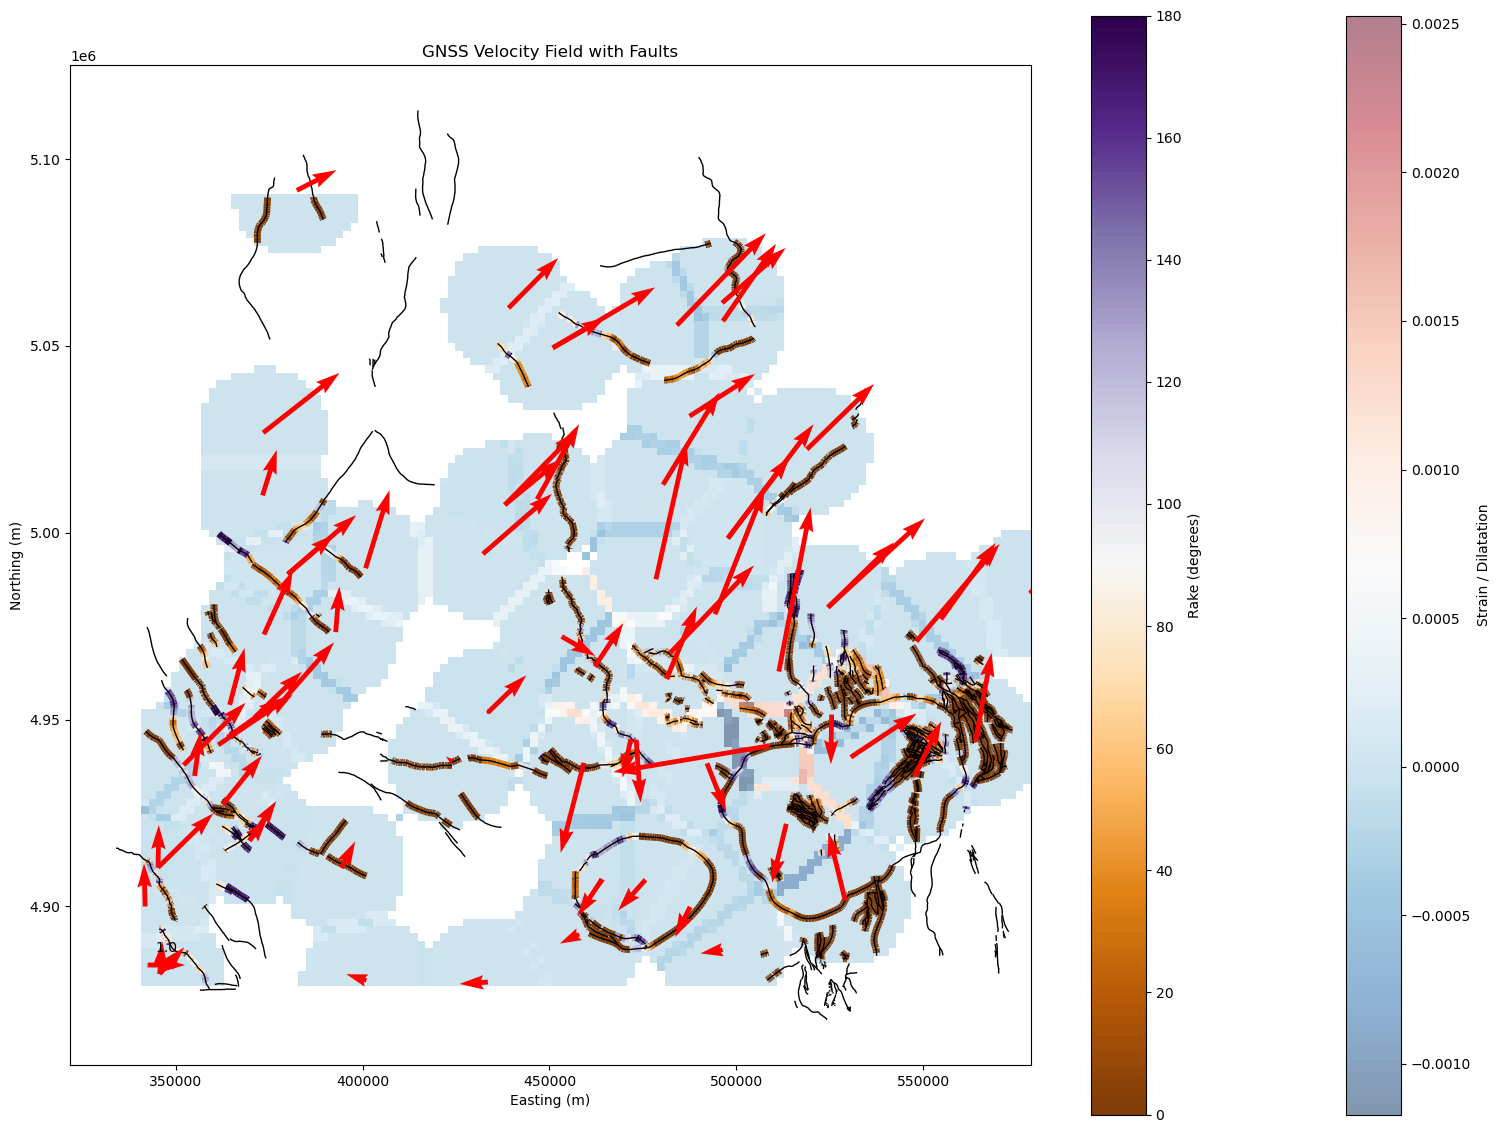

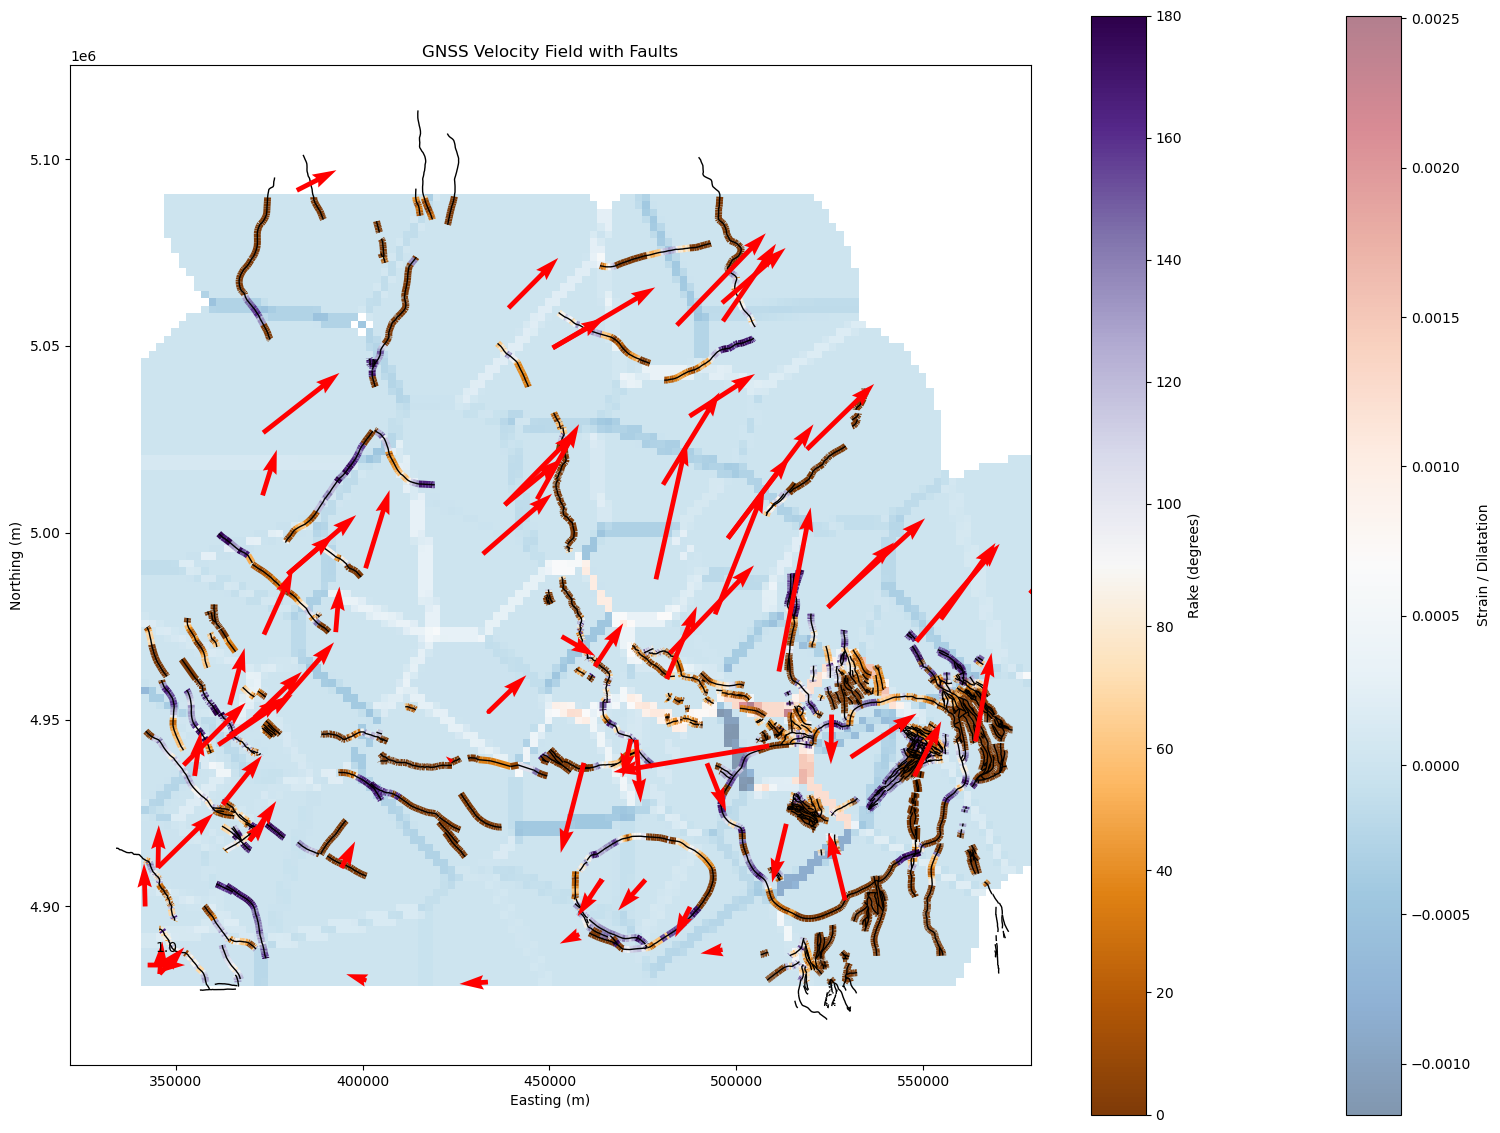

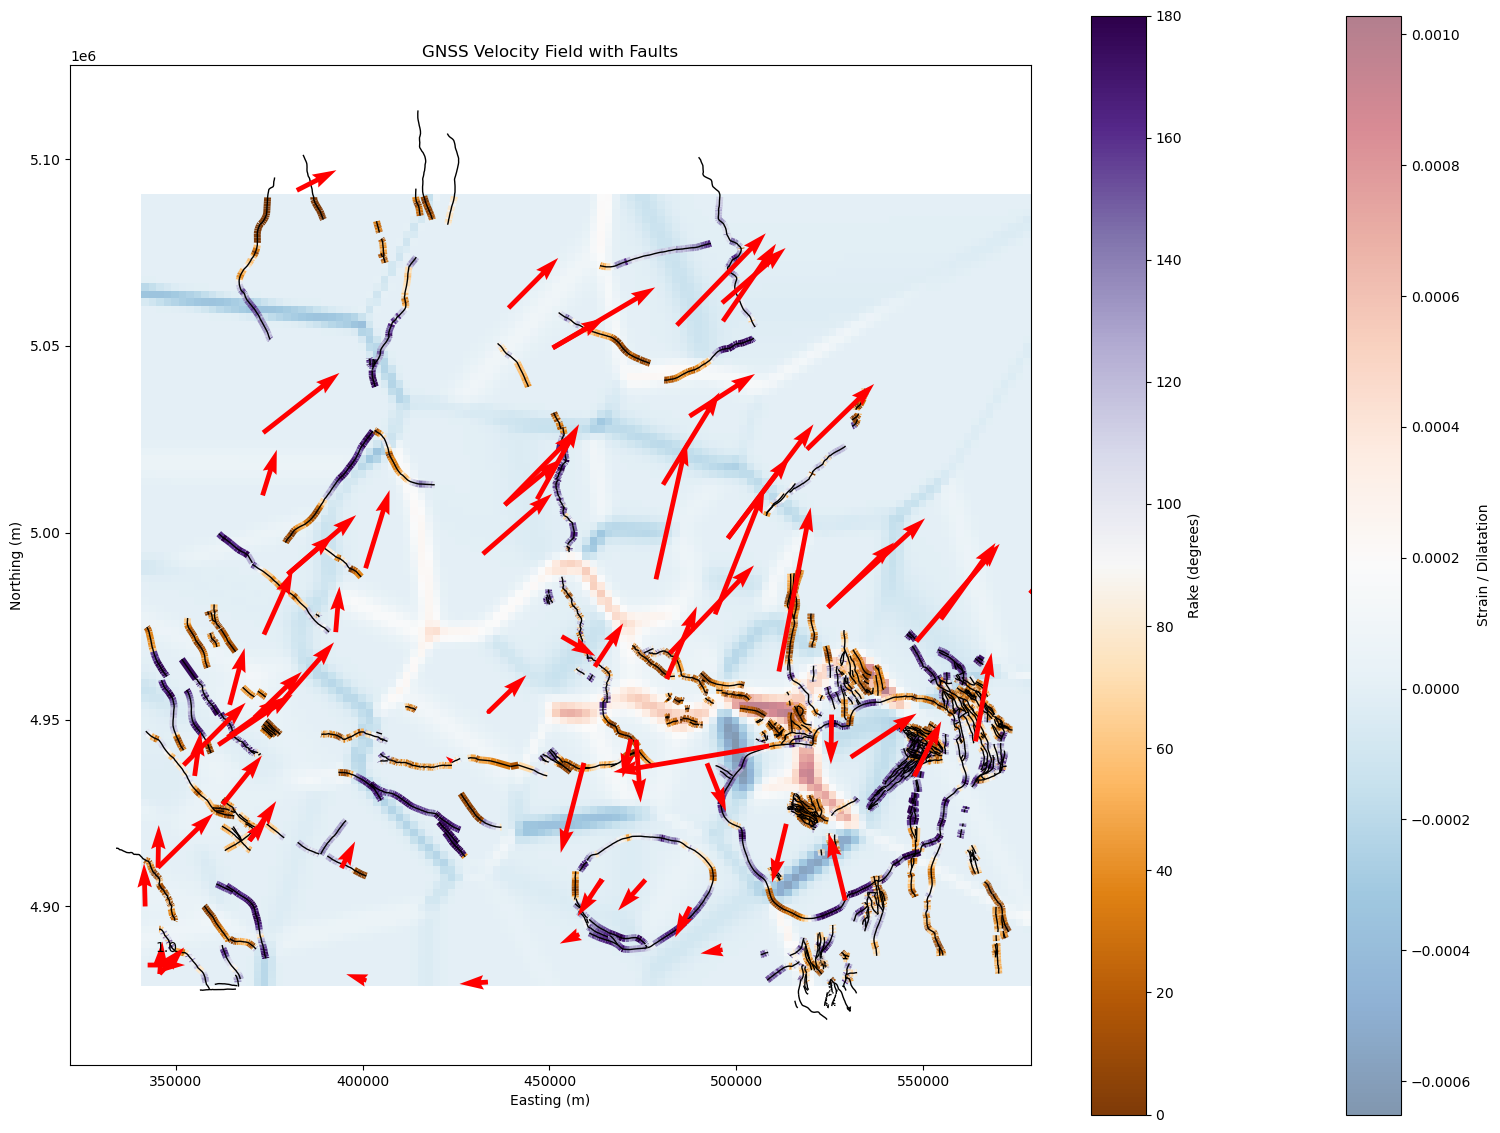

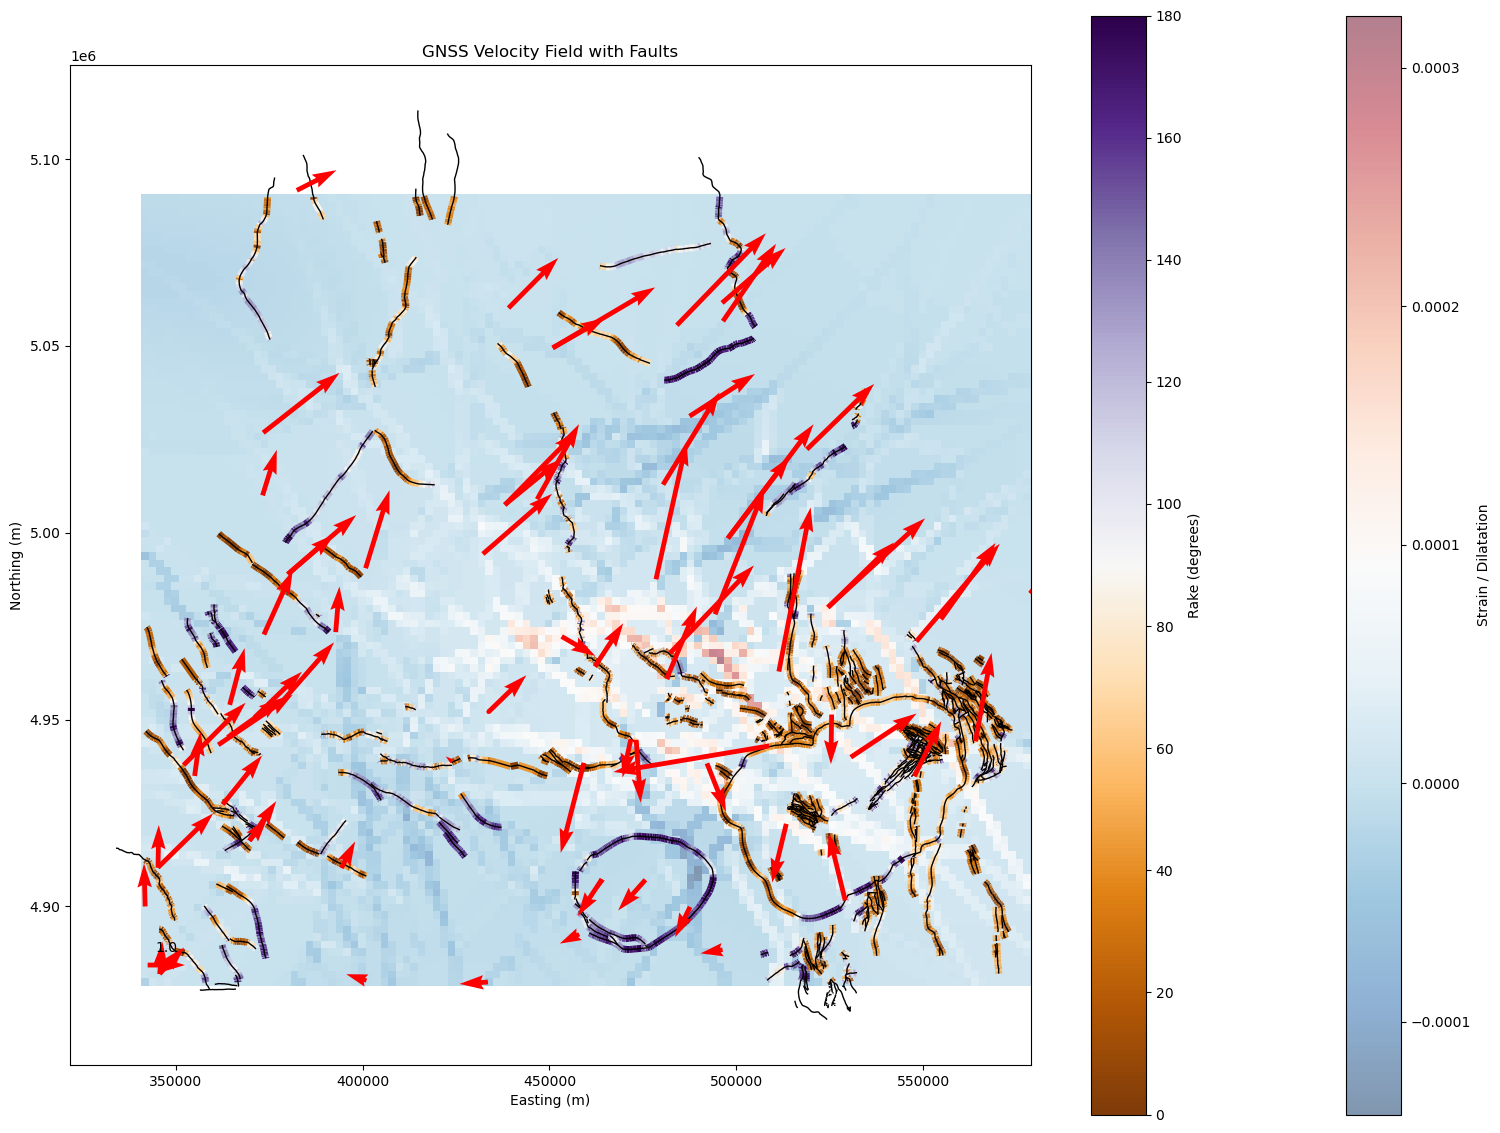

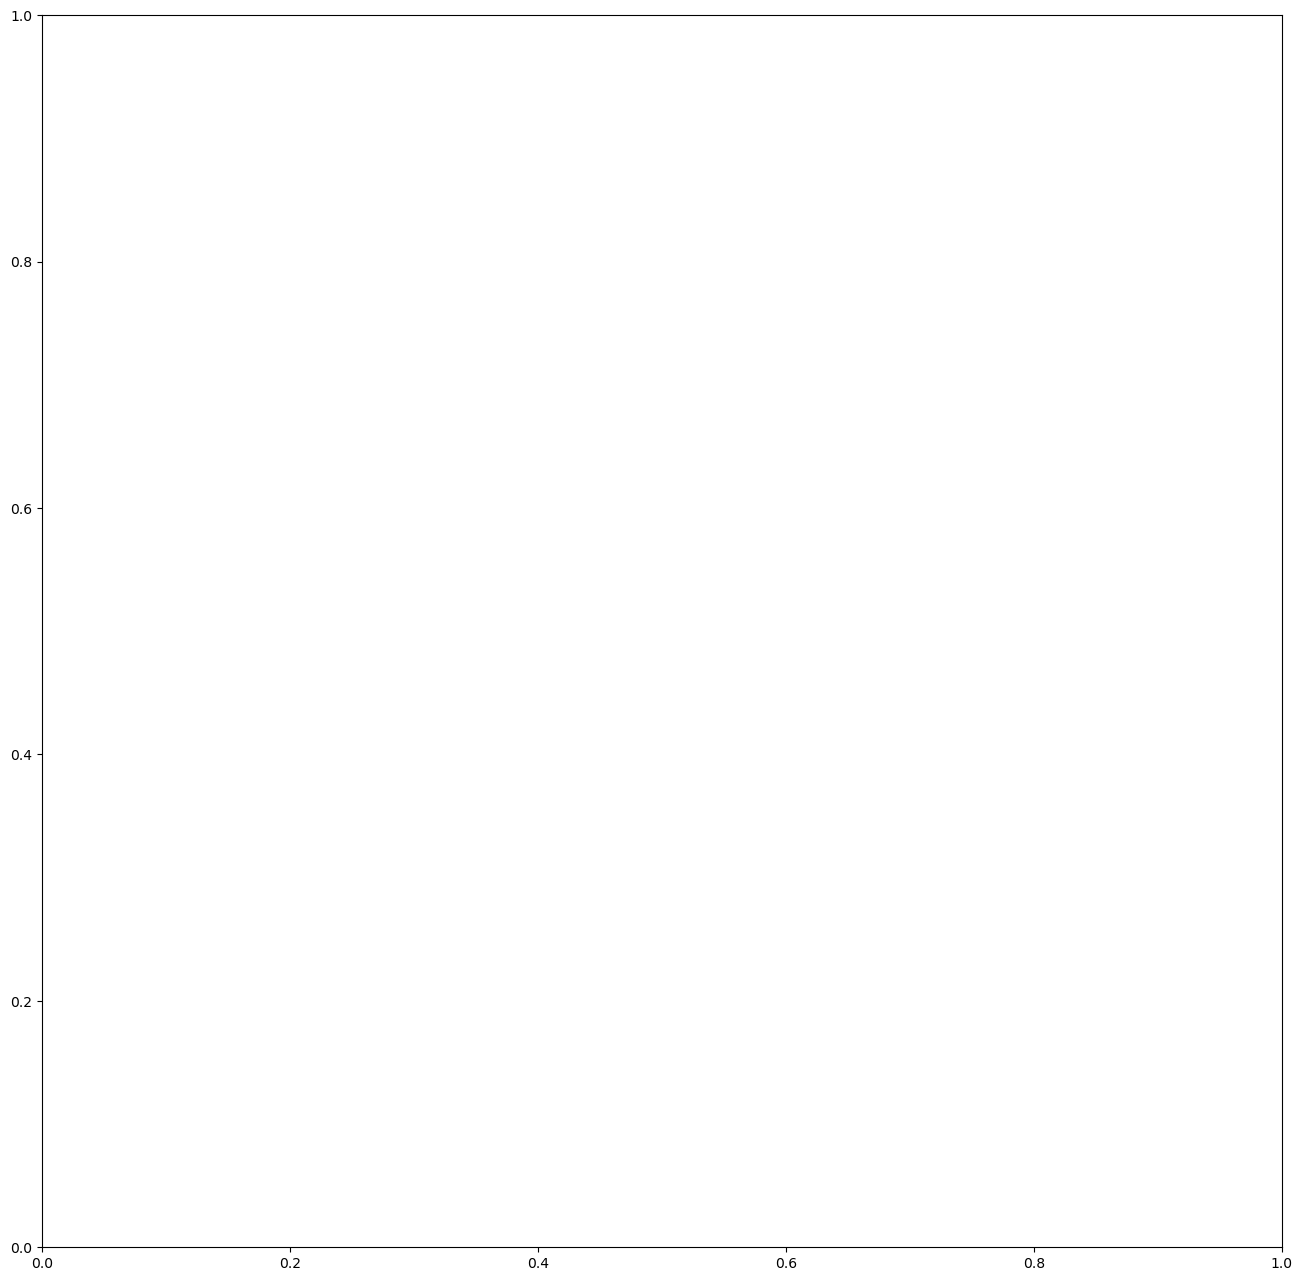

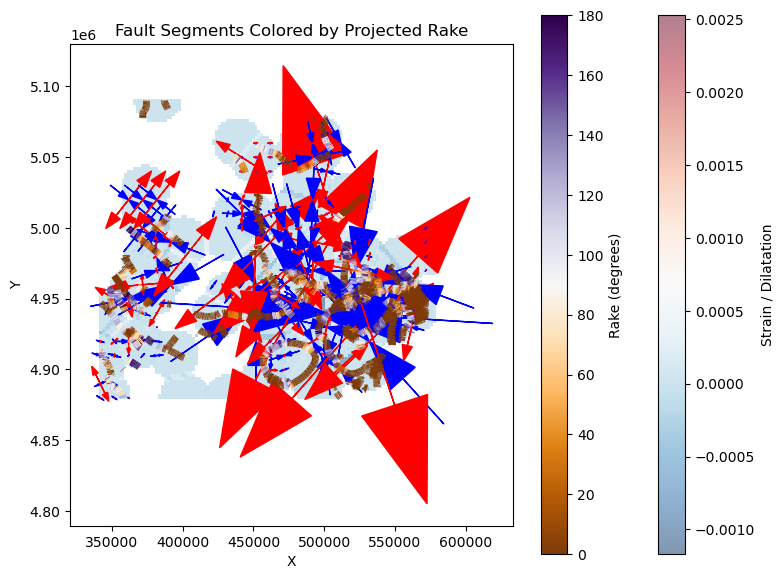

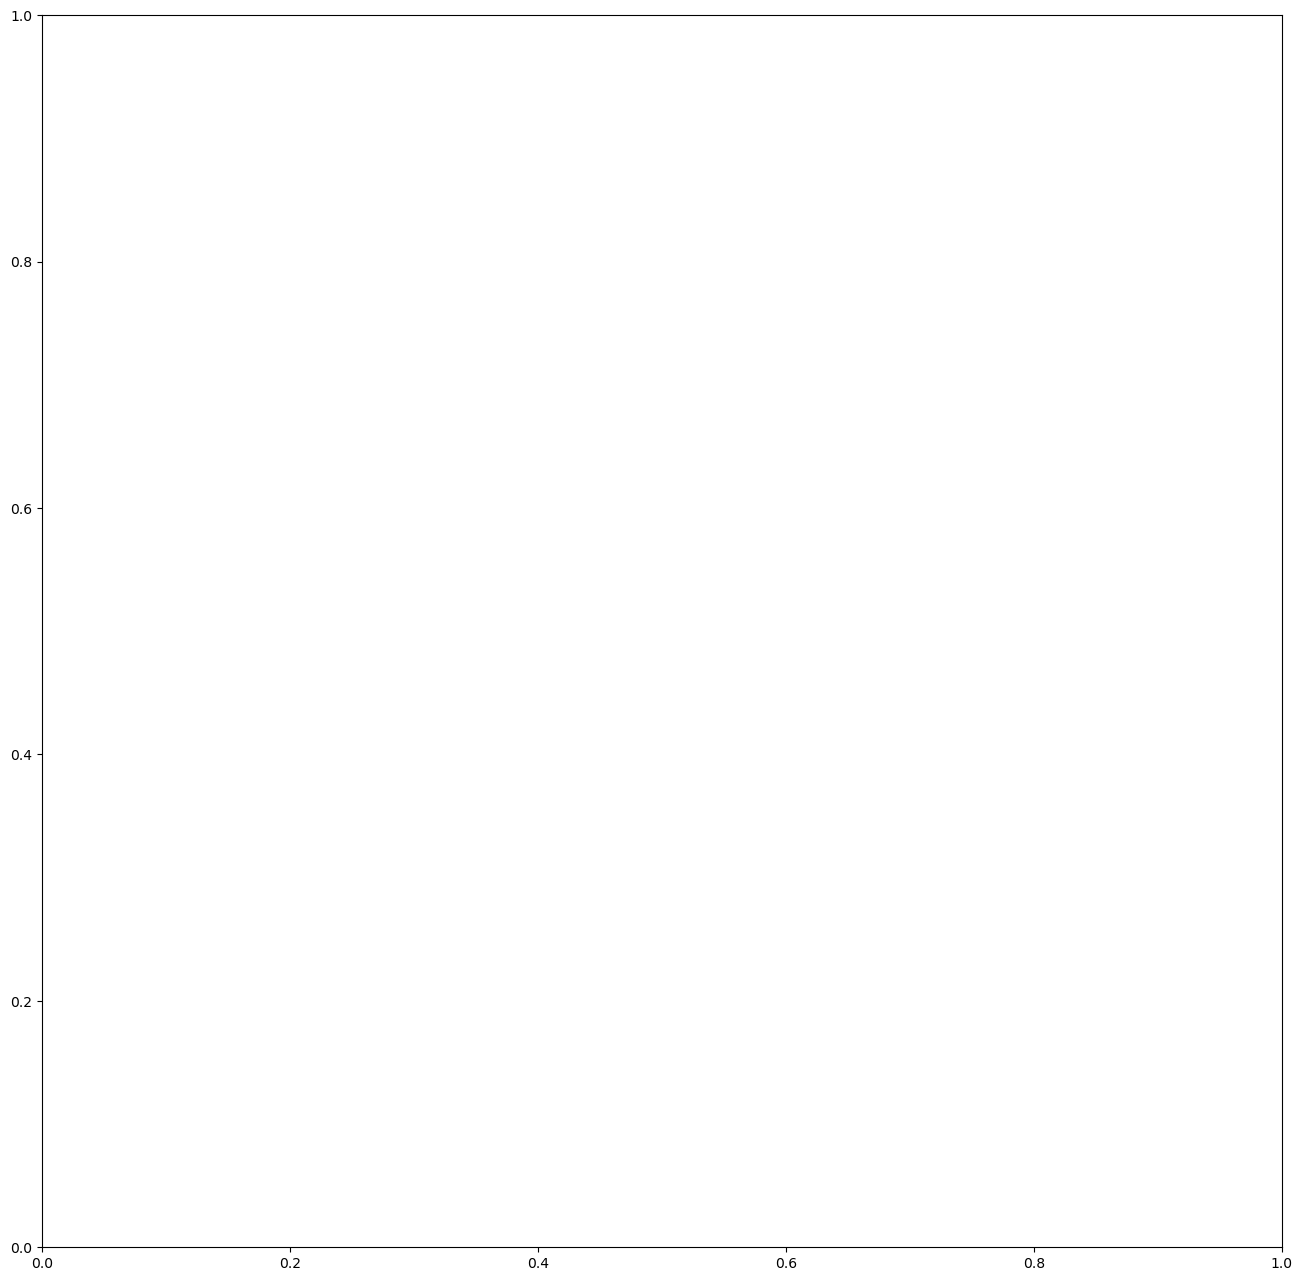

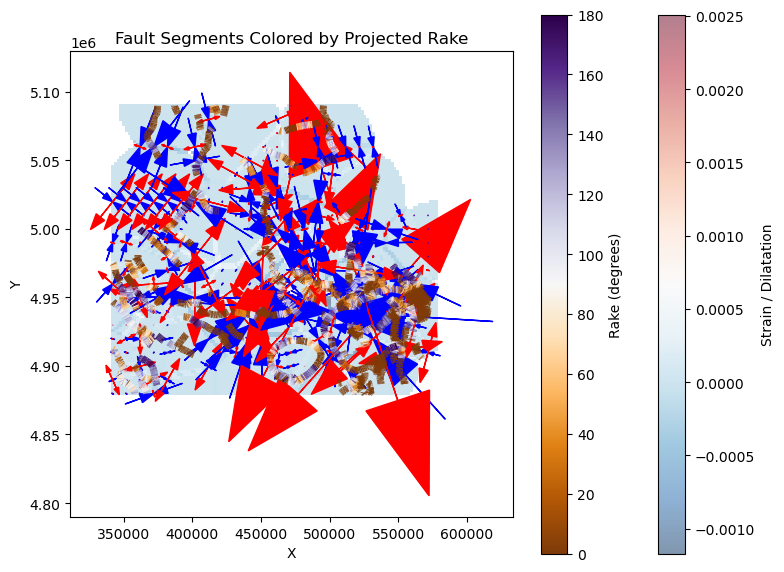

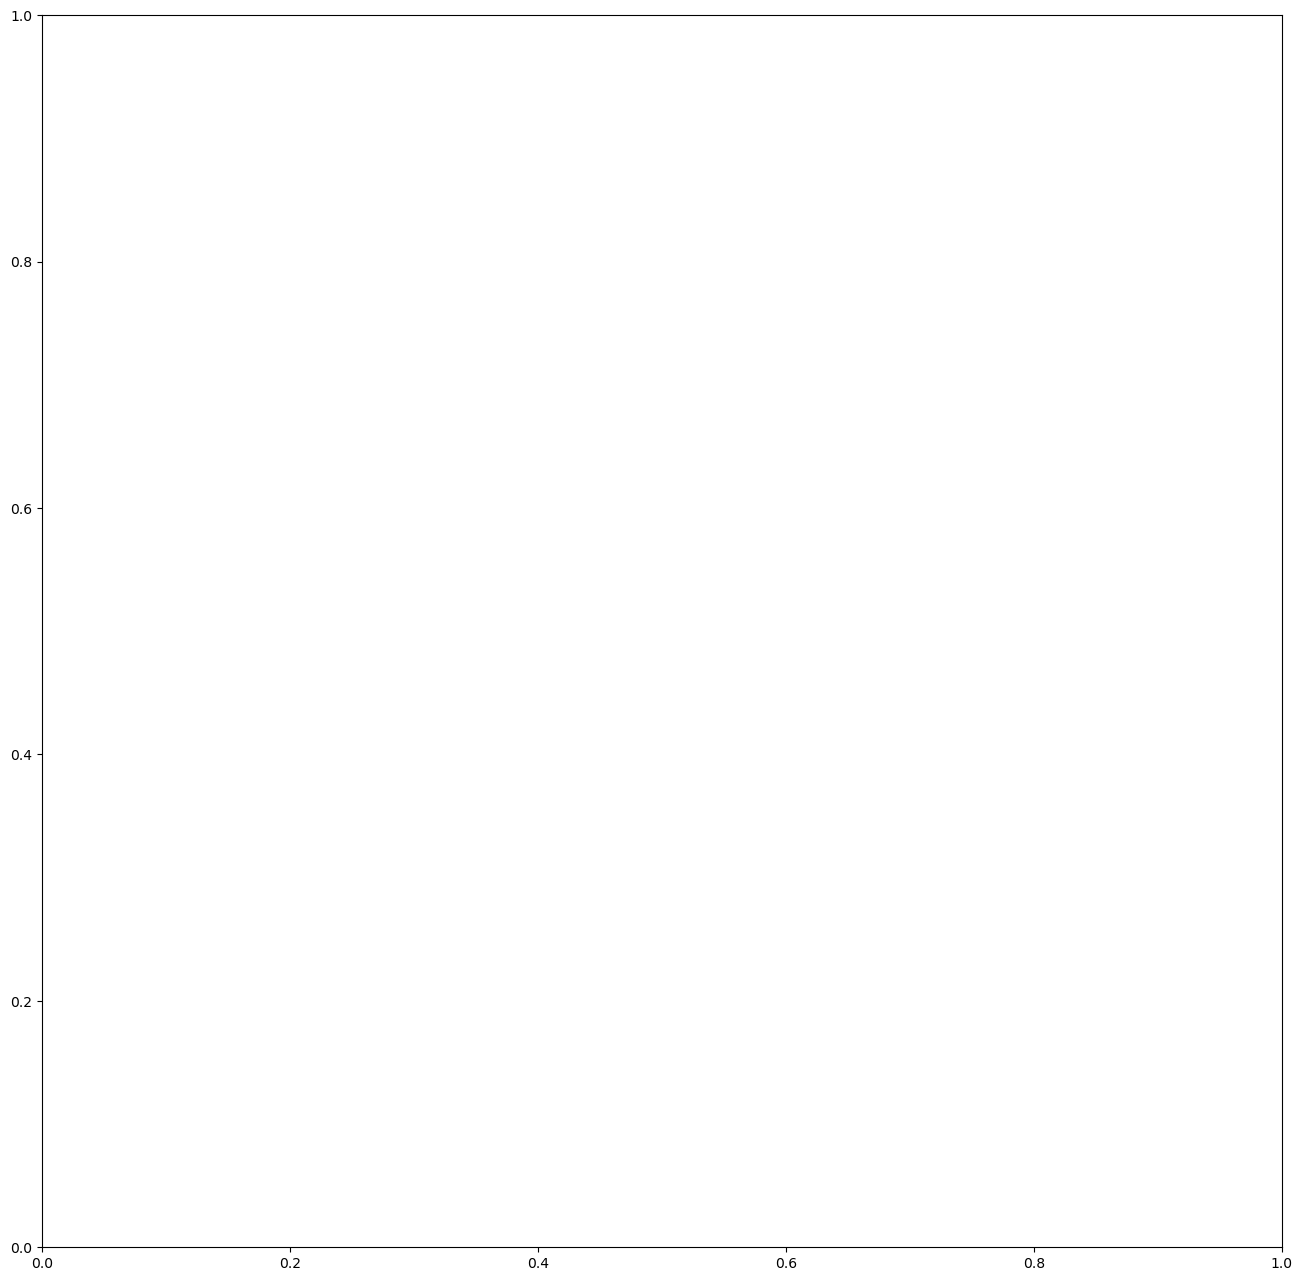

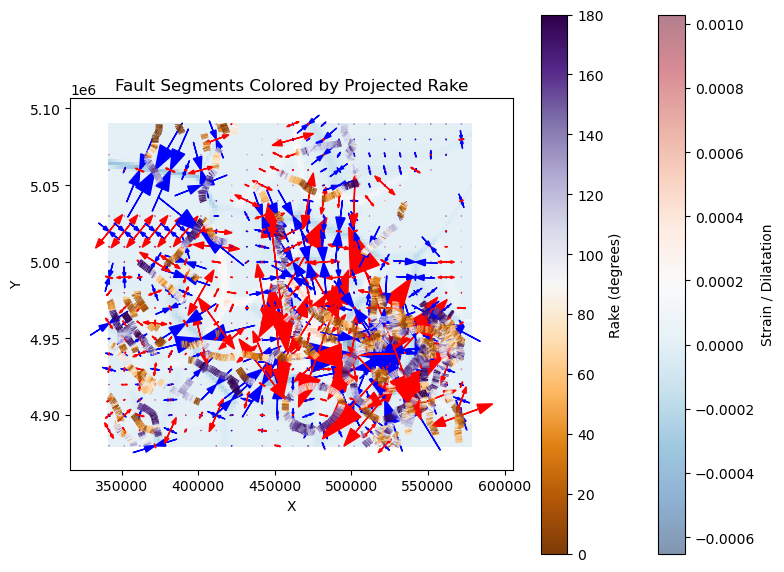

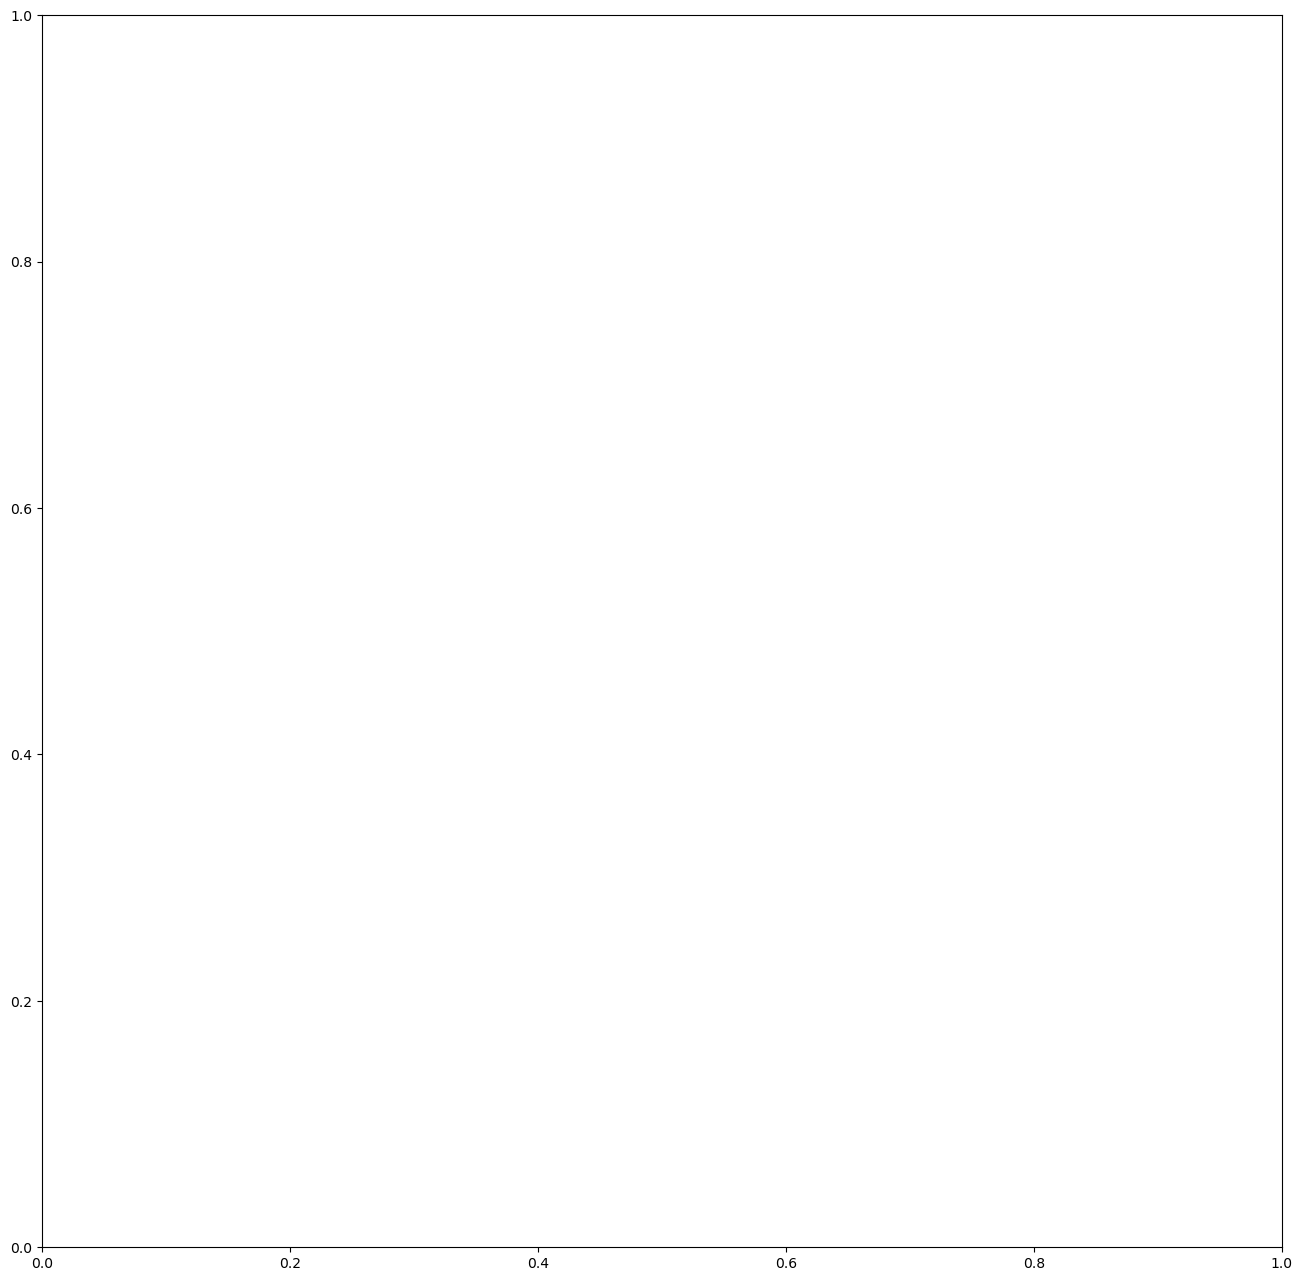

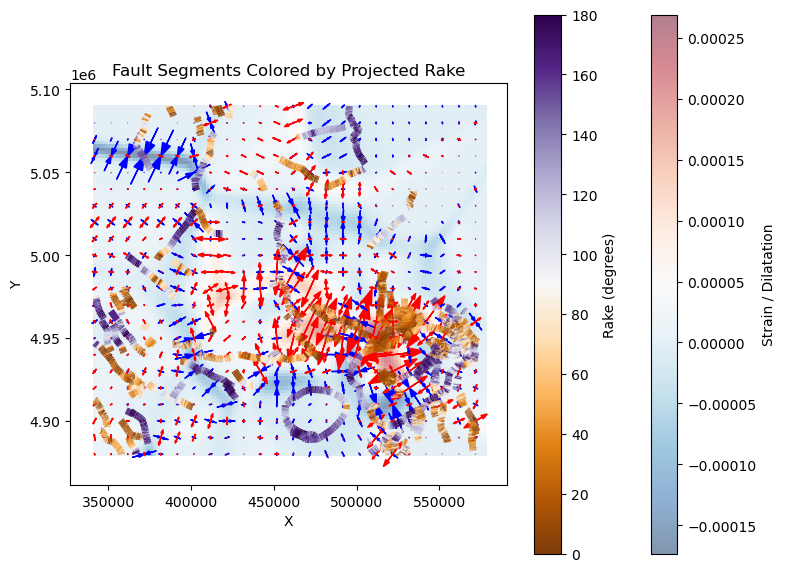

In [90]:
# 1. Grid GNSS (auto-project)
for sigma in [500,1000,5000,30000]:
    X, Y, Ve, Vn, crs_proj = grid_gps_velocity(df.Longitude, df.Latitude, 
                                               df['East Velocity (mm/yr)'], df['North Velocity (mm/yr)'],
                                                spacing=2000,   # 2 km grid
                                                sigma=sigma      # 5 km smoothing
                                                )

    # 2. Strain
    exx, eyy, exy = compute_strain(X, Y, Ve, Vn)

    # 3. Faults → segments (auto reproject)
    segments = segment_faults_with_strike(faults, crs_proj)

    # 4. Sample strain
    segments = sample_strain_to_segments(X, Y, exx, eyy, exy, segments)

    # 5. Project strain
    segments = project_strain_segments(segments)

    # 6. Plot
    fig, ax = plt.subplots(figsize=(16,16))
    plot_fault_rake(segments, X, Y, background=exx+eyy,exx=None,eyy=None,exy=None, scale=1e-8,stride=5,ax=ax)# exx=exx,eyy=eyy,exy=exy, scale=1e-8,stride=5)
    plot_gps_velocities(
        lon=df.Longitude,
        lat=df.Latitude,
        ve=df.ve,#df['East Velocity (mm/yr)'],
        vn=df.vn,#df['North Velocity (mm/yr)'],
        raster_path=None,
        faults=faults,
        scale=1e-4,
        ax = ax
    )
    plt.show()

# 1. Grid GNSS (auto-project)
for sigma in [500,1000,5000,10000]:
    X, Y, Ve, Vn, crs_proj = grid_gps_velocity(df.Longitude, df.Latitude, 
                                               df['East Velocity (mm/yr)'], df['North Velocity (mm/yr)'],
                                                spacing=2000,   # 2 km grid
                                                sigma=sigma      # 5 km smoothing
                                                )

    # 2. Strain
    exx, eyy, exy = compute_strain(X, Y, Ve, Vn)

    # 3. Faults → segments (auto reproject)
    segments = segment_faults_with_strike(faults, crs_proj)

    # 4. Sample strain
    segments = sample_strain_to_segments(X, Y, exx, eyy, exy, segments)

    # 5. Project strain
    segments = project_strain_segments(segments)

    # 6. Plot
    fig, ax = plt.subplots(figsize=(16,16))
    plot_fault_rake(segments, X, Y, background=exx+eyy,exx=exx,eyy=eyy,exy=exy, scale=1e-8,stride=5)
    plt.show()



In [7]:
# 1. Grid GNSS (auto-project)
X, Y, Ve, Vn, crs_proj = grid_gps_velocity([-1,0,1,0], [0,1,0,-1], 
                                           [-1,0,1,0],[0,1,0,-1],
                                            spacing=0.5,   # 2 km grid
                                            sigma=1     # 5 km smoothing
                                            )

: 

In [8]:
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString

# 1. Grid GNSS (auto-project)
X, Y, Ve, Vn, crs_proj = grid_gps_velocity([-1,0,1,0], [0,1,0,-1], 
                                           [-1,0,1,0],[0,1,0,-1],
                                            spacing=1,   # 2 km grid
                                            sigma=1     # 5 km smoothing
                                            )

# 2. Strain
exx, eyy, exy = compute_strain(X, Y, Ve, Vn)

# -----------------------------
# 4. Create SINGLE fault segment
# -----------------------------
fault_line = LineString([(-0.5, 0), (0.5, 0)])

faults = gpd.GeoDataFrame(
    [{"geometry": fault_line}],
    crs="EPSG:4326"
)

# segment it (you already have this function)
segments = segment_faults_with_strike(faults,crs_proj)

# -----------------------------
# 5. Sample strain to segment
# -----------------------------
segments = sample_strain_to_segments(X, Y, exx, eyy, exy, segments)

# -----------------------------
# 6. Project strain
# -----------------------------
segments = project_strain_segments(segments)

# -----------------------------
# 7. Plot
# -----------------------------
fig, ax = plt.subplots()
plot_fault_rake(
    segments,
    X, Y,
    background=exx + eyy,
    exx=exx,
    eyy=eyy,
    exy=exy,
    scale=1,
    stride=3,
    ax = ax
)
plot_gps_velocities(
    lon=[-1,0,1,0],
    lat=[0,1,0,-1],
    ve=Ve,
    vn=Vn,
    raster_path=None,
    faults=faults,
    scale=1,
    ax = ax
)
plt.show()

: 

In [ ]:
segments

array([[[-5.64936777e-09,  7.00497733e-06],
        [ 4.66469626e-08,  6.63315612e-06],
        [ 7.76717358e-08,  6.26876539e-06],
        ...,
        [-1.57427167e-05,  7.77371052e-07],
        [-1.38403331e-05,  6.30703498e-07],
        [-1.23128889e-05,  6.34467483e-07]],

       [[ 2.00990825e-07,  8.34242421e-06],
        [ 2.57372681e-07,  7.93092427e-06],
        [ 2.87103548e-07,  7.52387470e-06],
        ...,
        [-1.72877225e-05,  1.08057981e-06],
        [-1.53169283e-05,  8.87827063e-07],
        [-1.37266660e-05,  8.84238723e-07]],

       [[ 5.44289077e-07,  1.11725093e-05],
        [ 6.08915983e-07,  1.07053649e-05],
        [ 6.38685703e-07,  1.02395954e-05],
        ...,
        [-1.97197770e-05,  1.31753641e-06],
        [-1.77107271e-05,  1.08776879e-06],
        [-1.60357725e-05,  1.07721031e-06]],

       ...,

       [[-5.69886326e-06,  1.61450524e-05],
        [-4.10089991e-06,  1.62736793e-05],
        [-2.01865825e-06,  1.63913608e-05],
        ...,
     